<h2 style="
    font-family: 'Times New Roman', Times, serif;
    color: white;
    font-weight: bold;
    font-style: italic;
">
    Phạm Hoàng Duy
</h2>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

<h2 style="font-family:'Times New Roman'; color:cyan;">
    <b><i>Exploratory Data Analysis</i></b>
</h2>

In [ ]:
df = pd.read_csv("../../data/creditcard.csv")
df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


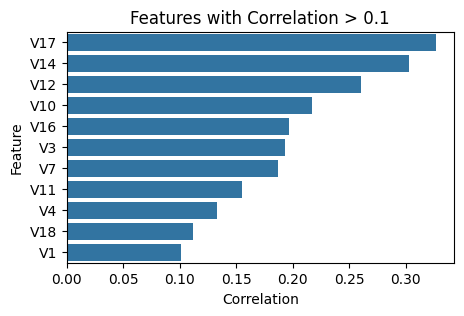

In [ ]:
features = df.corr()['Class'].drop('Class').abs()
features = features[features > 0.1].sort_values(ascending=False)

plt.figure(figsize=(5,3))
sns.barplot(x=features.values, y=features.index)

plt.title("Features with Correlation > 0.1")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.show()

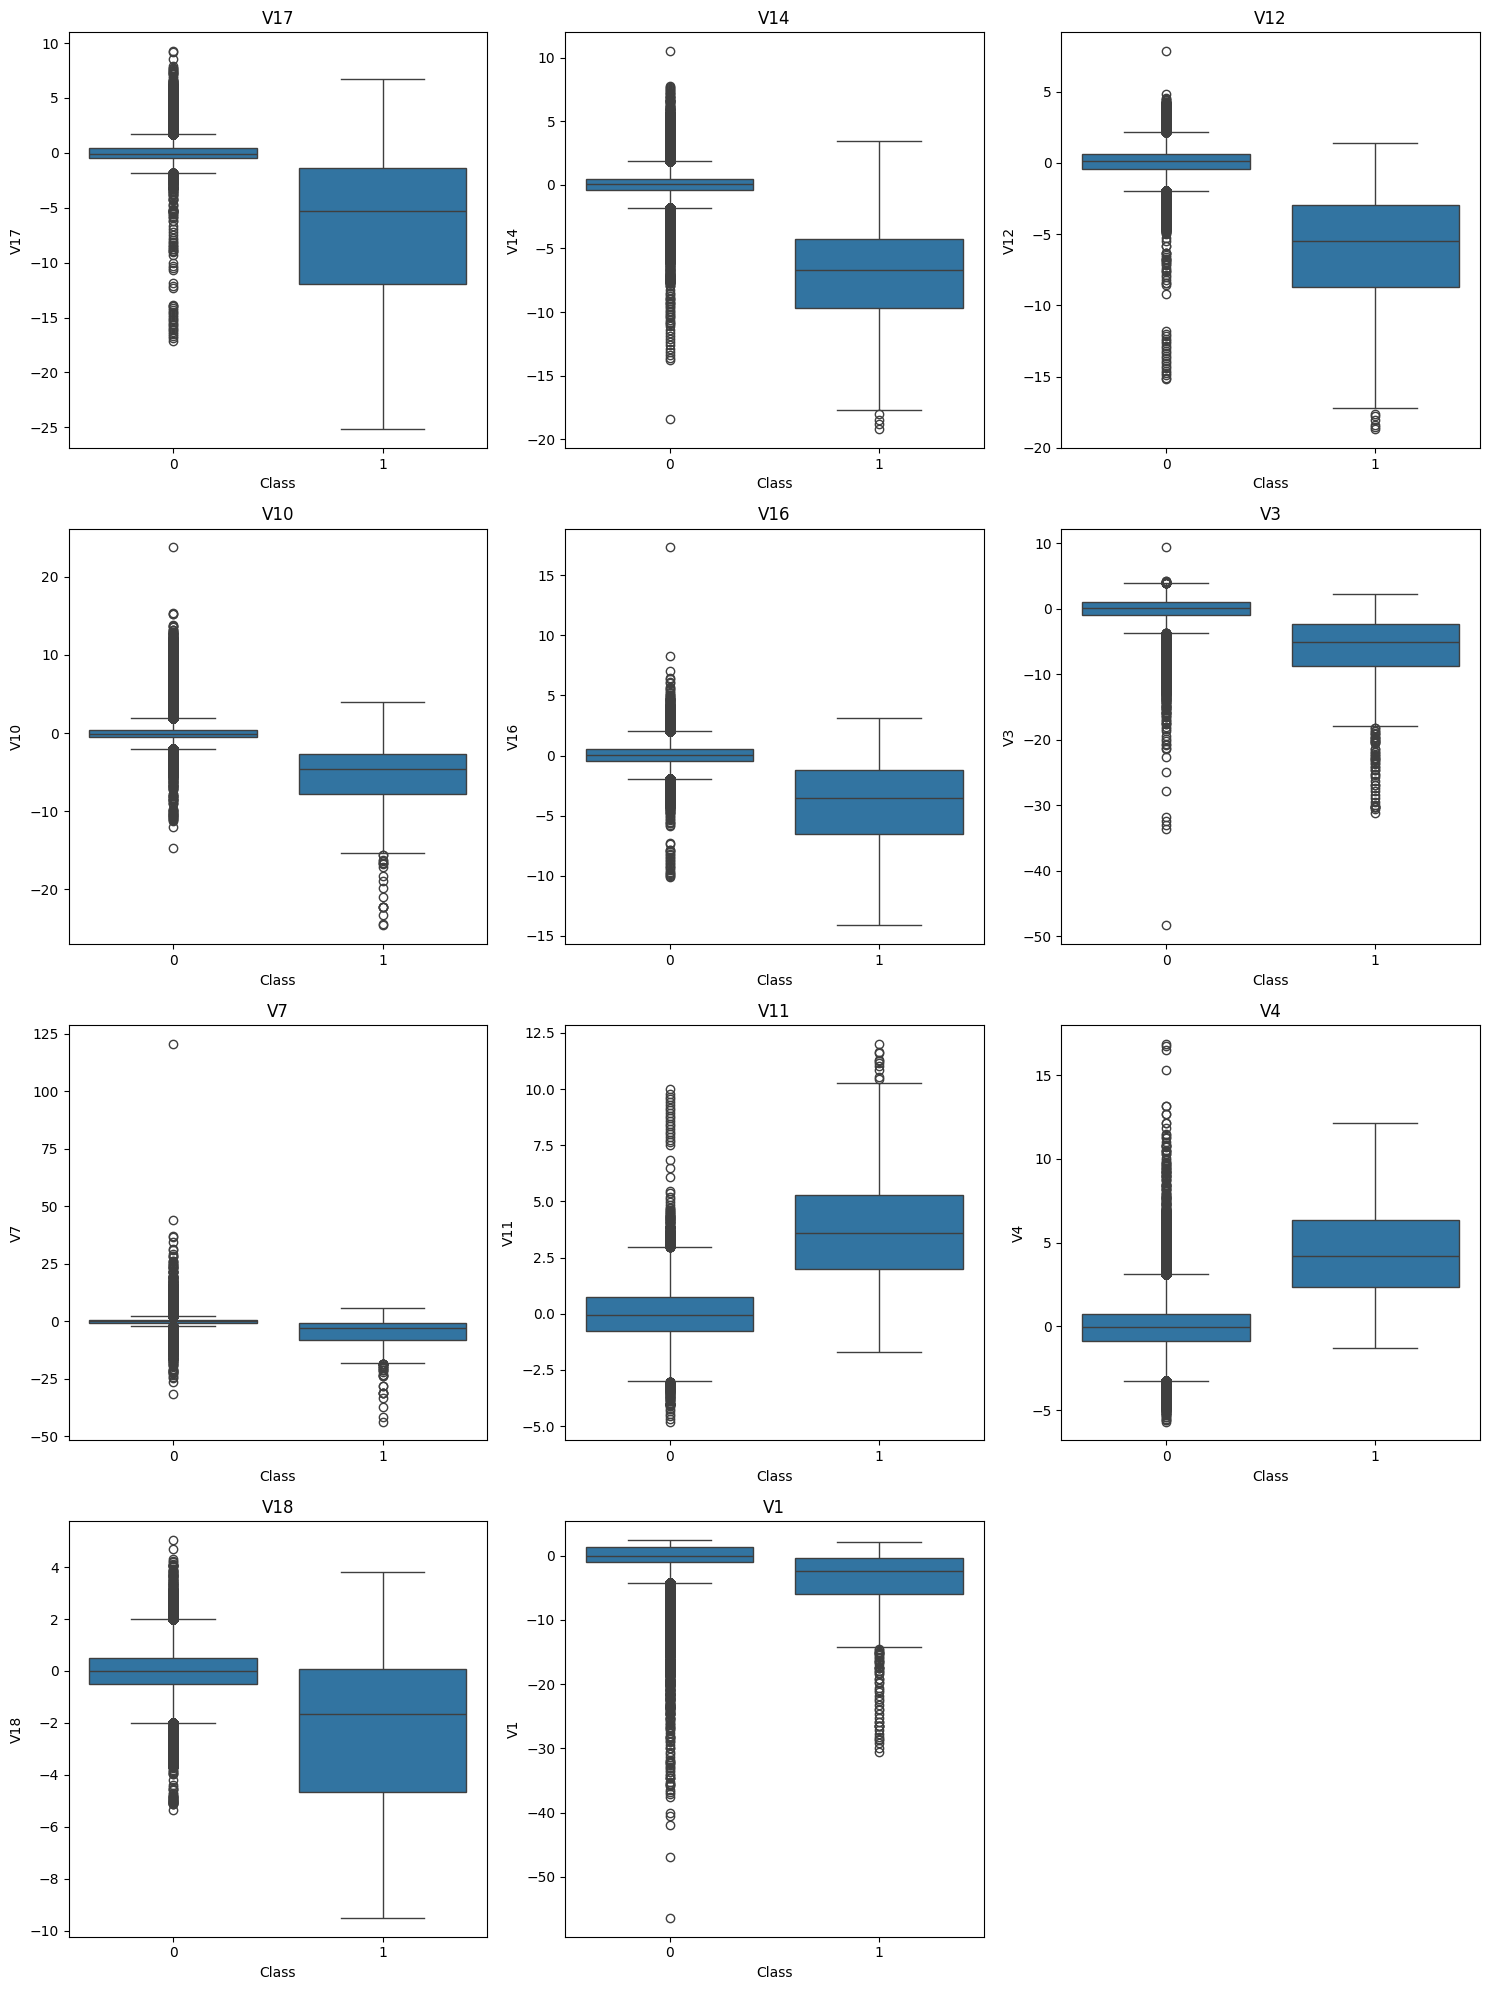

In [ ]:
c = 3
r = math.ceil(len(features.index) / c)

plt.figure(figsize=(15, 5*r))

for i, f in enumerate(features.index, 1):
    plt.subplot(r, c, i)
    sns.boxplot(x='Class', y=f, data=df)
    plt.title(f)

plt.tight_layout()
plt.show()

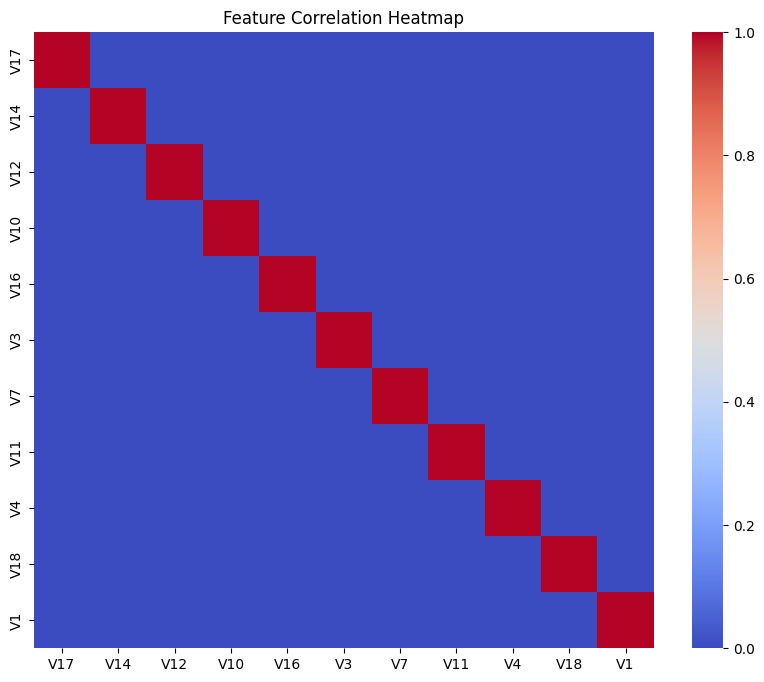

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df[features.index].corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Feature Correlation Heatmap")
plt.show()

<div style="
    font-family: 'Times New Roman', Times, serif;
    background-color: white;
    color: black;
    border-radius: 12px;
    padding: 15px 20px;
    border: 1px solid #ddd;
    line-height: 1.6;
    width: fit-content;
">
<b>Nhận xét:</b><br><br>

Qua biểu đồ correlation với biến <b>Class</b>, ta nhận thấy có khoảng 
<b>10 features</b> có hệ số tương quan tương đối mạnh 
(<i>|correlation| &gt; 0.1</i>). Điều này cho thấy các biến này có 
mối quan hệ đáng kể với việc phân loại giao dịch 
<b>gian lận (fraud)</b> và <b>bình thường (normal)</b>.<br><br>

Những feature này có khả năng đóng vai trò quan trọng trong việc 
xây dựng mô hình dự đoán, vì sự thay đổi của chúng có xu hướng 
liên quan đến sự thay đổi của biến <b>Class</b>.
</div>